In [1]:
# import features
import pandas as pd
# acitvity entropy
df_entropy = pd.read_csv('../output/data_cleaned/activity_entropy_rates.csv')
print(df_entropy.shape)

# early warning scores (physiological)
df_EWS = pd.read_csv('../output/data_cleaned/Mian_warning_score.csv')
df_EWS.columns = ['patient_id', 'date', 'early_warning_score']


# sleep quality
df_sleep_quality = pd.read_csv('../output/sleep_score/sleep_quality_score_by_duration.csv')
df_sleep_quality = df_sleep_quality.drop(columns= ['sum', 'mean','scaled_sleep_quality_sum']).copy()
df_sleep_quality.columns = ['patient_id', 'date', 'sleep_quality_score']

# agitation
df_agitation = pd.read_csv('../output/data_cleaned/agitation_daily_counts.csv')

# uti
df_uti = pd.read_csv('../output/data_cleaned/uti_daily.csv')

merged_df = df_entropy
# merge dataframes
for df in [df_EWS, df_sleep_quality, df_agitation, df_uti]:
    print(df.shape)
    merged_df = pd.merge(merged_df, df, on=['patient_id', 'date'], how='outer')
    
# only consider the patients without NA in the following analysis (as the analysis itself will be individualized anyway)
analysis_df = merged_df.dropna(subset=['sleep_quality_score']).dropna(subset=['early_warning_score']).dropna(subset=['entropy_rate']).copy()
analysis_df =  analysis_df.fillna(0)

print(analysis_df.shape)
analysis_df 

(2722, 3)
(2160, 3)
(800, 3)
(115, 3)
(265, 3)
(660, 7)


,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
219,0f352,2019-06-26,0.669008,0.0,2.233437,0.0,1.0
221,0f352,2019-06-28,0.613697,0.0,1.516700,0.0,0.0
222,0f352,2019-06-29,0.615494,0.0,-0.010261,0.0,1.0
223,0f352,2019-06-30,0.514768,0.0,2.607387,0.0,0.0
250,16f4b,2019-04-28,0.651879,0.0,-1.319084,0.0,0.0
...,...,...,...,...,...,...,...
2694,f220c,2019-06-06,0.620975,0.0,-2.627908,0.0,0.0
2696,f220c,2019-06-08,0.527123,0.0,2.607387,0.0,0.0
2706,f220c,2019-06-19,0.527442,0.0,2.607387,0.0,0.0
2709,f220c,2019-06-22,0.608841,0.0,2.607387,0.0,0.0


In [2]:
id_select = "ec812"
df_person = analysis_df[analysis_df['patient_id'] == id_select].copy()
df_person 

,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen
2528,ec812,2019-04-09,0.684974,0.0,-0.010261,0.0,0.0
2529,ec812,2019-04-10,0.614688,0.0,0.316945,0.0,0.0
2530,ec812,2019-04-11,0.680348,0.0,-0.446535,0.0,0.0
2531,ec812,2019-04-12,0.668105,0.0,-0.337467,0.0,0.0
2532,ec812,2019-04-13,0.655223,0.0,0.363689,0.0,0.0
...,...,...,...,...,...,...,...
2594,ec812,2019-06-21,0.661363,0.0,-0.337467,0.0,0.0
2595,ec812,2019-06-22,0.623560,0.0,0.862288,0.0,0.0
2596,ec812,2019-06-23,0.708682,0.0,0.316945,0.0,0.0
2597,ec812,2019-06-24,0.656330,0.0,0.280589,0.0,0.0


In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Sort by patient_id and date
patient_data = df_person.sort_values(by=['patient_id', 'date']).reset_index(drop=True)

features = [
    'entropy_rate',
    'early_warning_score',
    'sleep_quality_score',
    'agitation_counts',
    'uti_happen'
]

previous_n = 10  # number of past days used as baseline

X_list = []
y_list = []
scalers = []  # optional: store scalers for inspection/debugging

for i in range(len(patient_data) - previous_n):
    
    # ---------- historical window ----------
    X_raw = patient_data.iloc[i:i+previous_n][features].values
    
    # ---------- fit scaler on historical data only ----------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    # ---------- next-day observation ----------
    y_raw = patient_data.iloc[i+previous_n][features].values.reshape(1, -1)
    y_scaled = scaler.transform(y_raw)
    
    X_list.append(X_scaled)
    y_list.append(y_scaled.squeeze())  # shape (n_features,)
    scalers.append(scaler)

# Convert to arrays
X = np.array(X_list)  # shape: (n_windows, previous_n, n_features)
y = np.array(y_list)  # shape: (n_windows, n_features)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (60, 10, 5)
y shape: (60, 5)


In [66]:
# Parameters
n_estimators = 100  # Number of trees
contamination = 0.2  # Expected proportion of anomalies: I want to use the previous days as baseline, so expect no/almost no anomaly here 
max_samples=0.8  # Number of samples used to train each tree (here I use fraction of total sample)

# Train Isolation Forest
iso_forest = IsolationForest(n_estimators=n_estimators,
                            contamination=contamination,
                            max_samples=max_samples,
                            random_state=42)

X_anomaly_list = []
y_anomaly_list = []
for n_input in range(len(X)): 
    iso_forest.fit(X[n_input])
    X_anomaly_list.append(iso_forest.predict(X[n_input]))
    y_anomaly_list.append(iso_forest.predict(y[n_input].reshape(1, -1)))

X_anomaly = np.array(X_anomaly_list)
y_anomaly = np.array(y_anomaly_list)

# df_anomaly_combined = pd.concat([pd.DataFrame(X_anomaly[0,]), pd.DataFrame(y_anomaly)], axis=0)
df_anomaly_combined = pd.concat([pd.DataFrame([np.nan]*previous_n), pd.DataFrame(y_anomaly)], axis=0)
df_anomaly_combined = df_anomaly_combined.rename(columns={df_anomaly_combined.columns[0]: "anomaly_FI"})

In [67]:
df_person_re = df_person.reset_index(drop = True)
df_anomaly_combined_re = df_anomaly_combined.reset_index(drop = True)
df_person_plot = pd.concat([df_person_re, df_anomaly_combined_re], axis=1).copy()

df_person_plot

,patient_id,date,entropy_rate,early_warning_score,sleep_quality_score,agitation_counts,uti_happen,anomaly_FI
0,f220c,2019-04-27,0.584277,2.0,2.607387,0.0,0.0,NaN
1,f220c,2019-04-28,0.539405,1.0,2.607387,0.0,0.0,NaN
2,f220c,2019-05-03,0.550437,1.0,0.862288,0.0,1.0,NaN
3,f220c,2019-05-05,0.758488,0.0,1.298563,0.0,1.0,NaN
4,f220c,2019-05-12,0.643946,1.0,1.734838,0.0,1.0,NaN
5,f220c,2019-05-15,0.632996,2.0,1.298563,0.0,0.0,NaN
6,f220c,2019-05-19,0.540110,1.0,-1.319084,0.0,1.0,NaN
7,f220c,2019-05-31,0.565897,1.0,-0.010261,0.0,1.0,NaN
8,f220c,2019-06-01,0.564593,0.0,2.607387,0.0,0.0,NaN
9,f220c,2019-06-02,0.629657,0.0,2.607387,0.0,0.0,NaN


In [57]:
pd.to_datetime(df_person_plot[df_person_plot.anomaly_FI == -1].date).dt.strftime('%m-%d').astype(str).values

array(['04-15', '04-17', '04-22', '04-24', '04-26', '05-21', '05-30',
       '06-03', '06-08'], dtype=object)

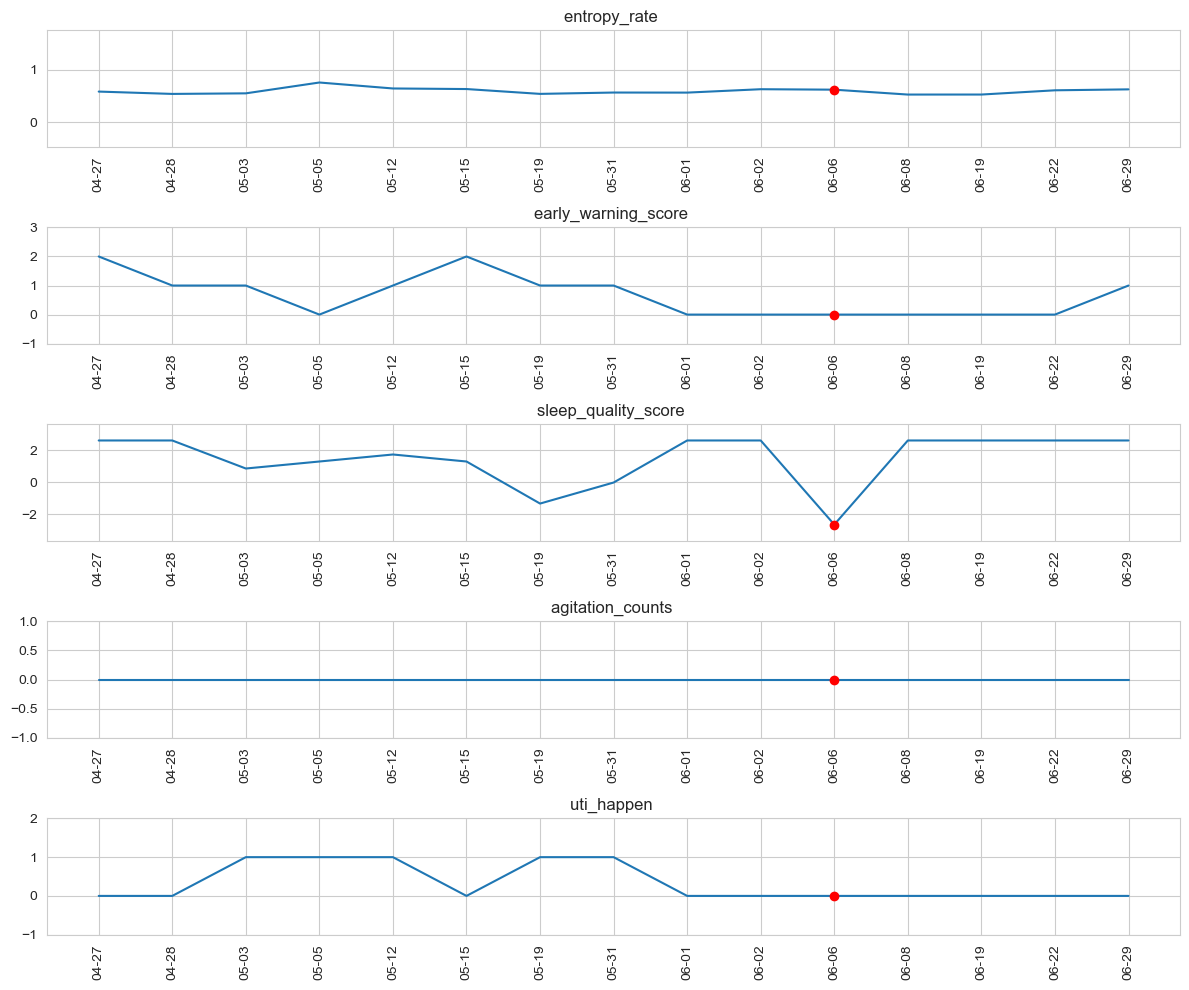

In [68]:
# Set the figure size
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
anomaly_dates = pd.to_datetime(df_person_plot[df_person_plot.anomaly_FI == -1].date).dt.strftime('%m-%d').astype(str).values

data_plot = df_person_plot[['date', 'entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts', 'uti_happen']].copy()
data_plot['date'] = pd.to_datetime(data_plot['date'])            
data_plot['date'] = data_plot['date'].dt.strftime('%m-%d')
data_plot['date'] = data_plot['date'].astype(str)             
data_plot.set_index('date', inplace=True)


# Plot each variable
for i, column in enumerate(data_plot.columns):
    plt.subplot(5, 1, i+1)  # 3x3 grid for 7 variables, including empty ones for better arrangement
    plt.plot(data_plot.index, data_plot[column], label=column)
    
    # # Highlight specific index in red
    plt.scatter(anomaly_dates, data_plot[column][anomaly_dates], color='red', label='anomaly', zorder=5)
       
    # Title and labels
    plt.title(f'{column} ')
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=90)
    
    # Optional: Adjusting the y-axis range to fit all data in the plots
    plt.ylim(data_plot[column].min() - 1, data_plot[column].max() + 1)

# Adjust layout and show plot
plt.tight_layout()

plt.savefig('../output/Anomaly_delirium/forest_isolation_sliding/anomaly_ForestIsolation_' + id_select + '.png', dpi=300)
plt.show()

# ALL IN ONE

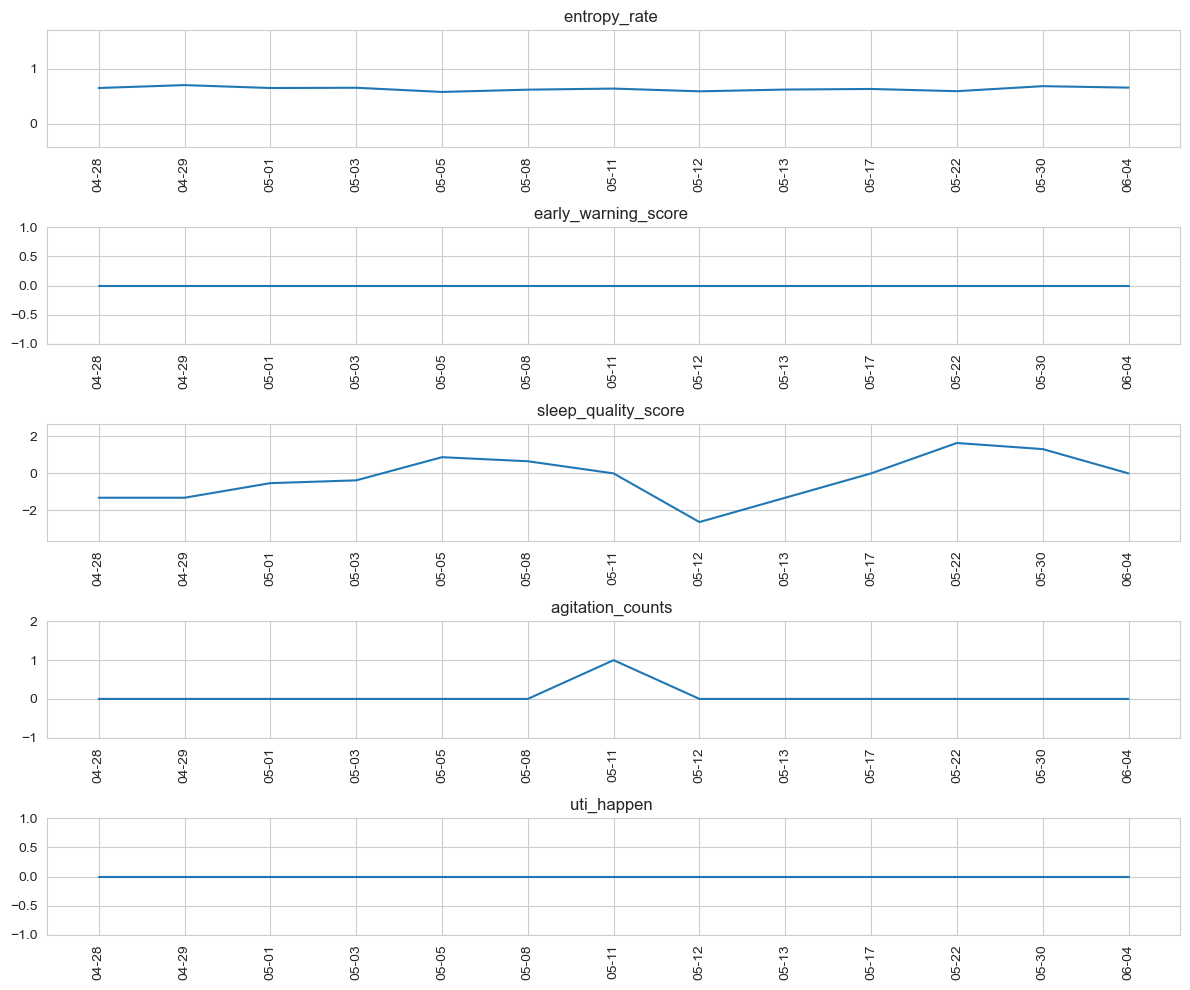

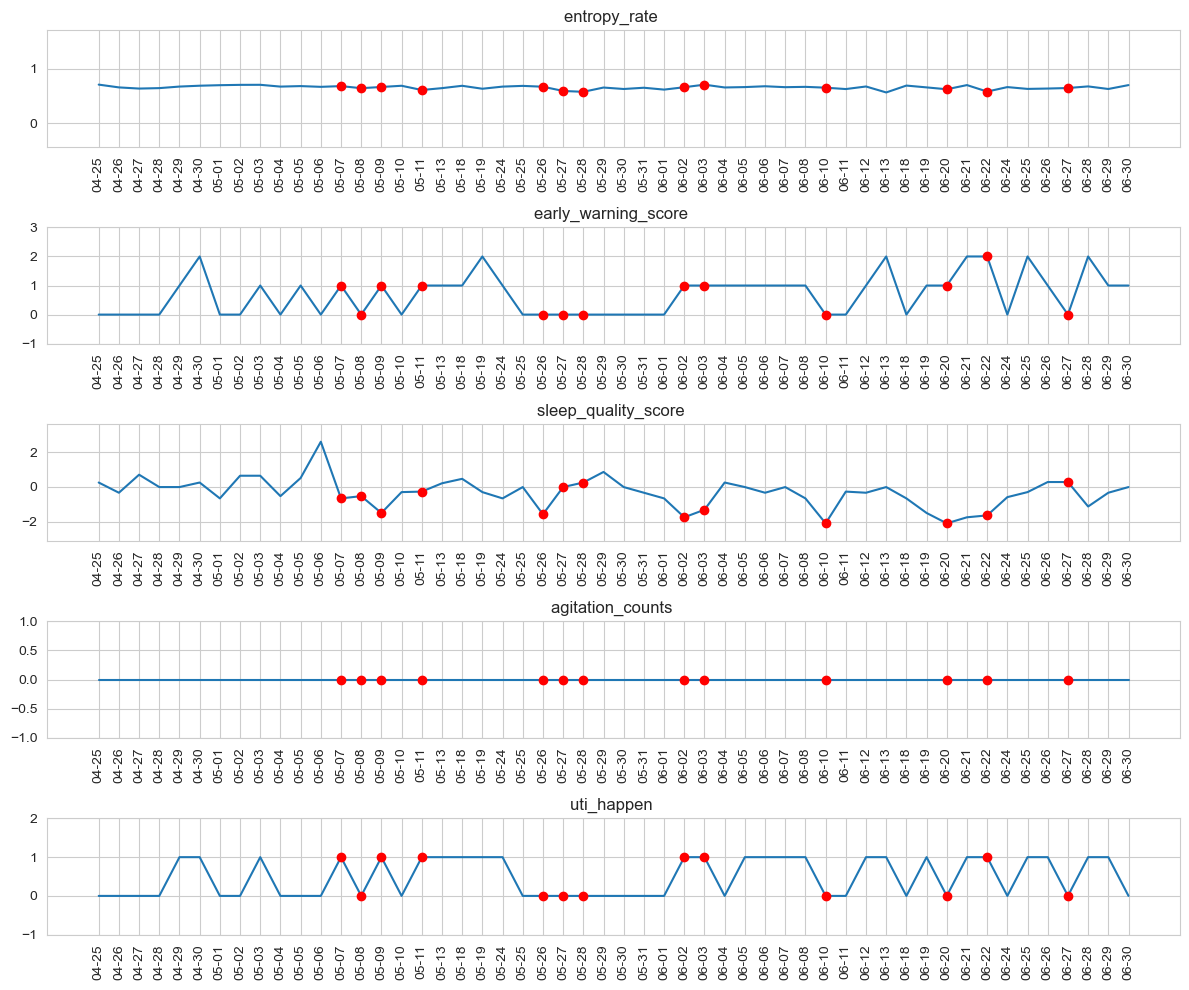

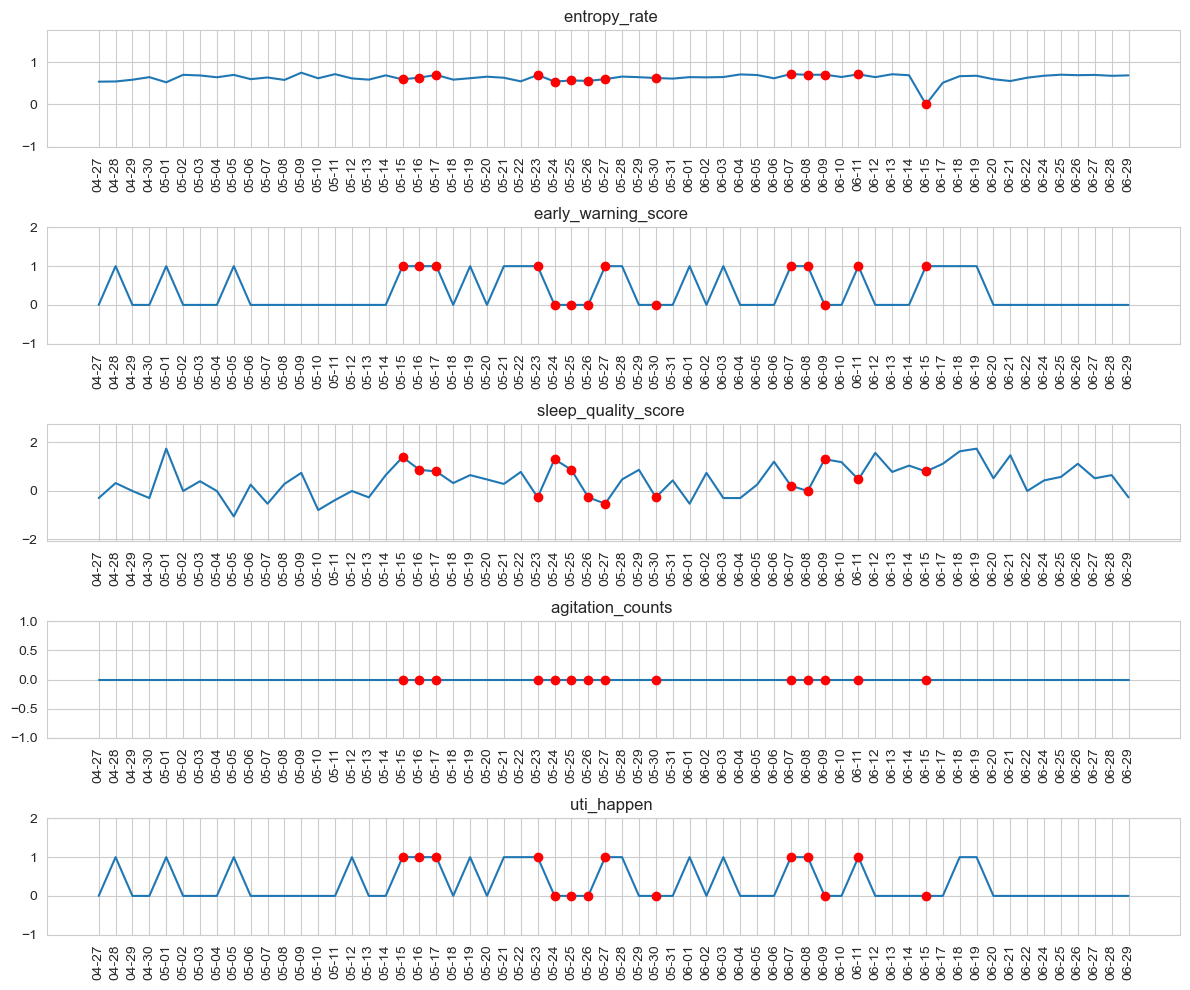

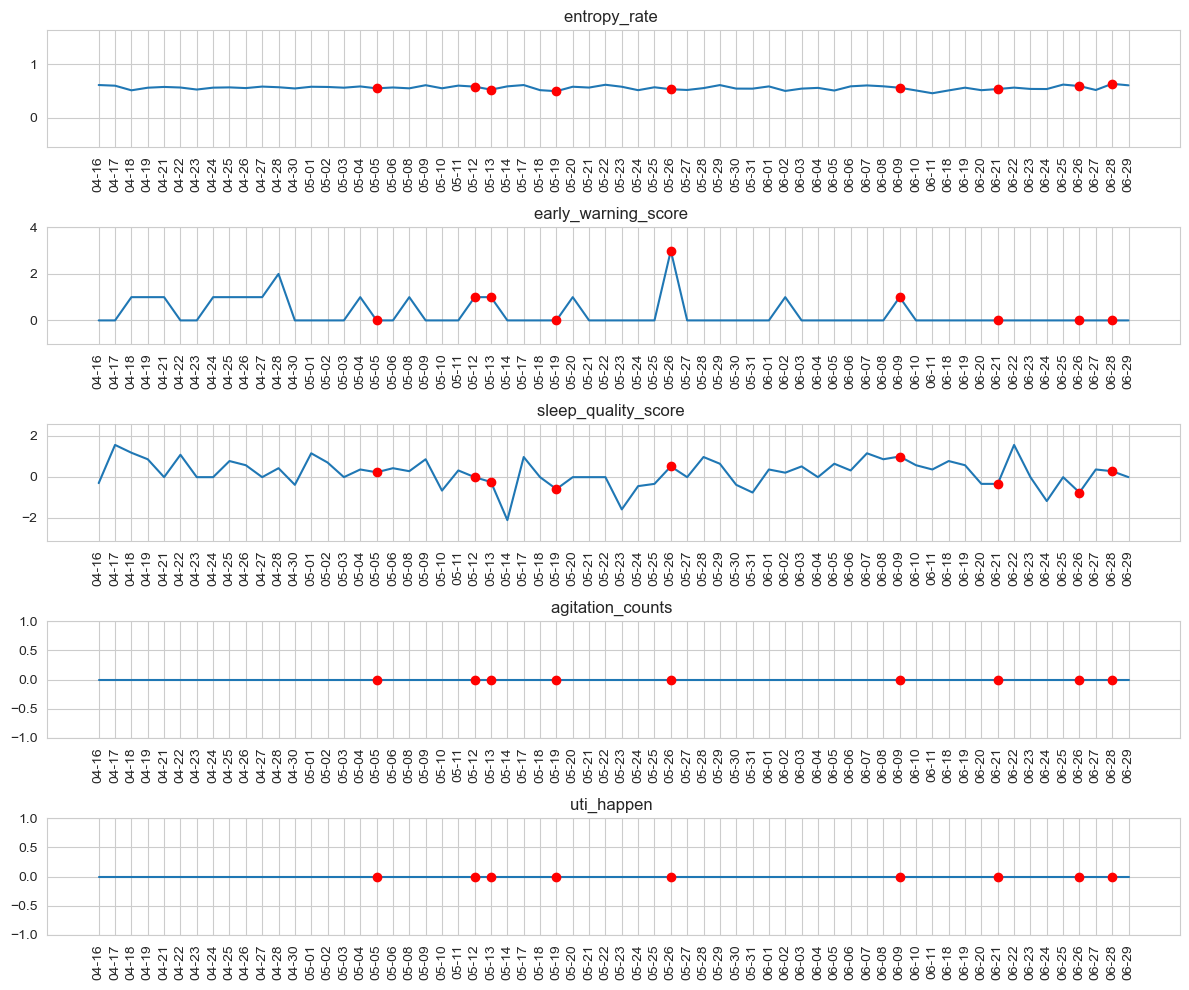

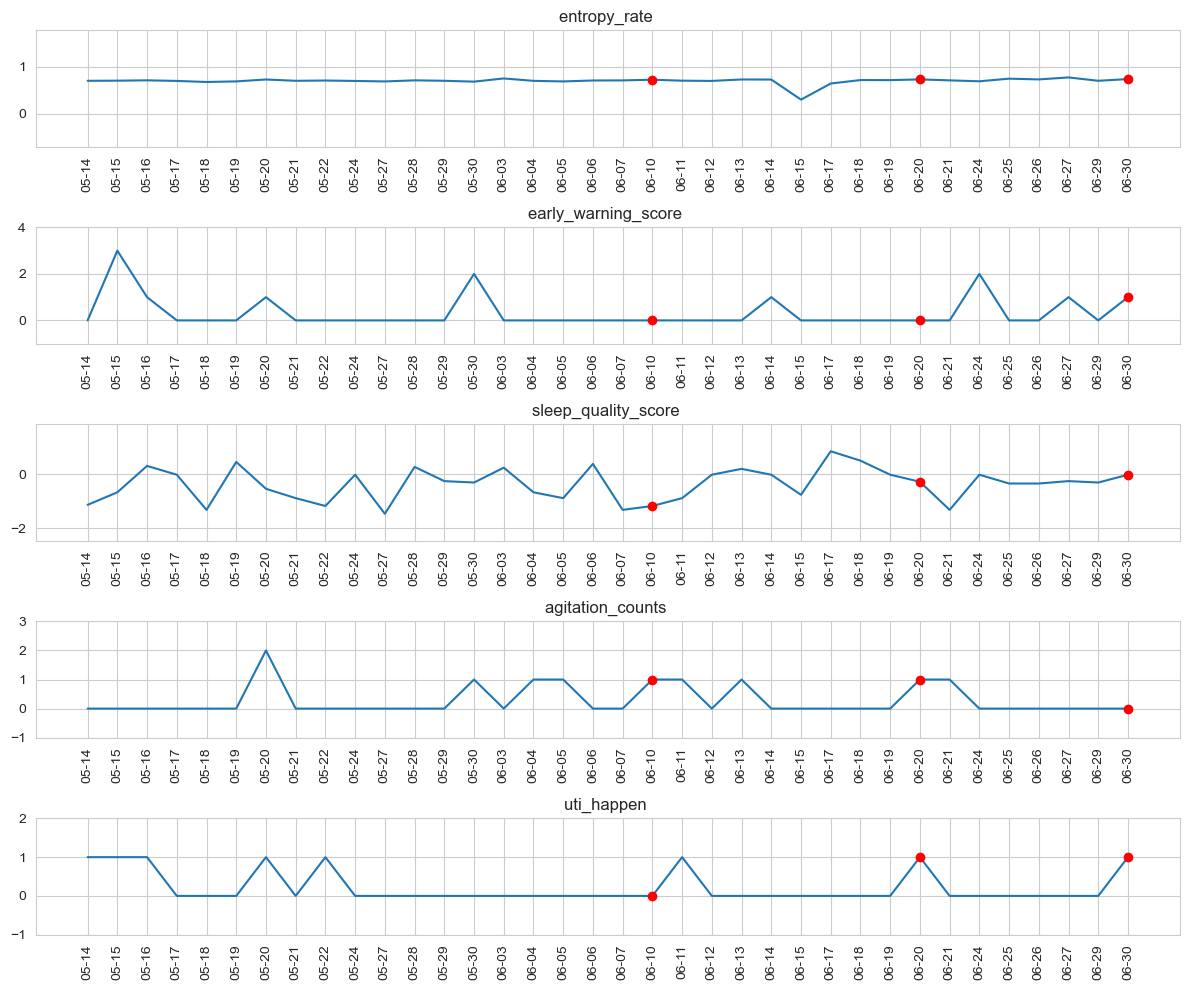

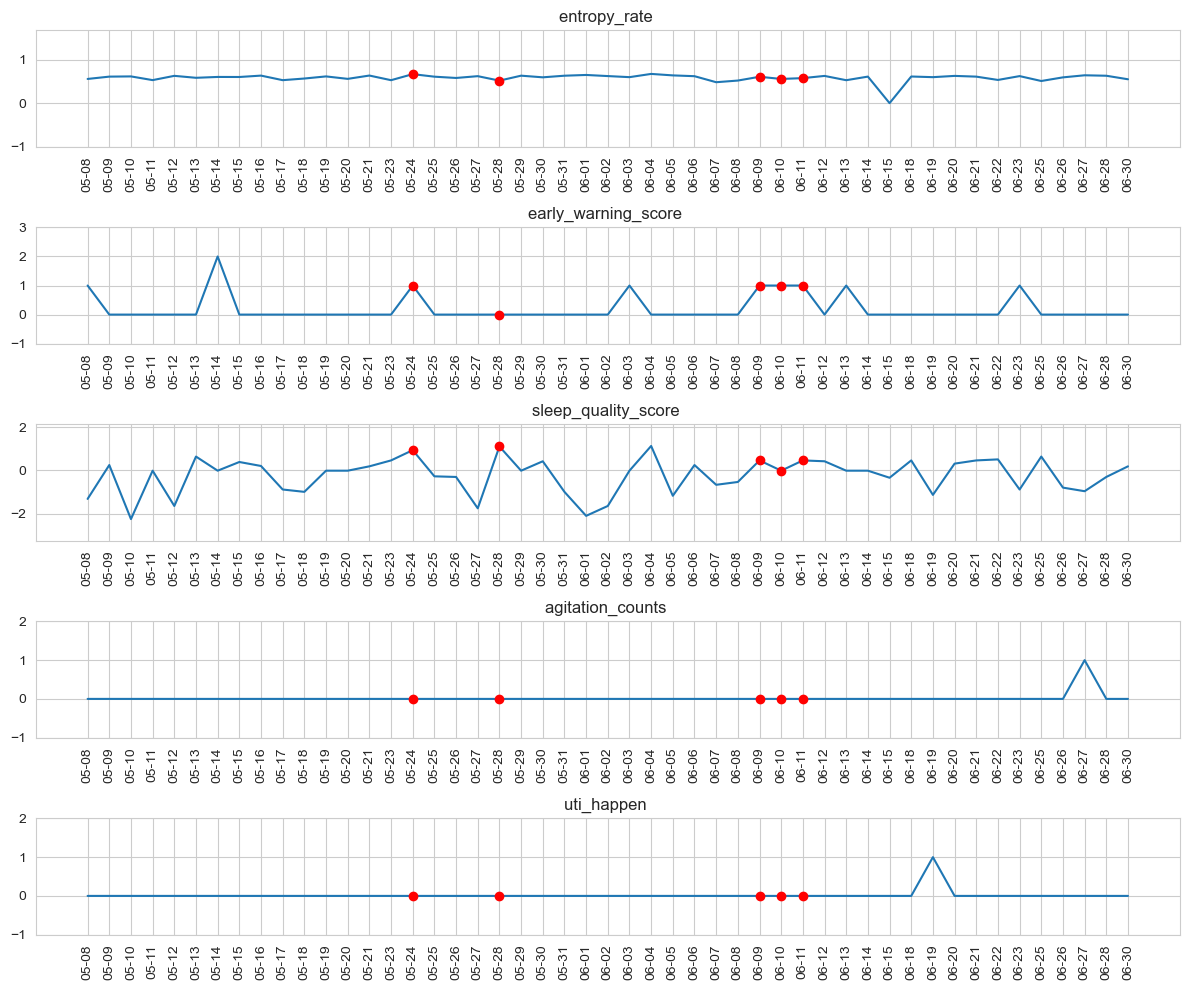

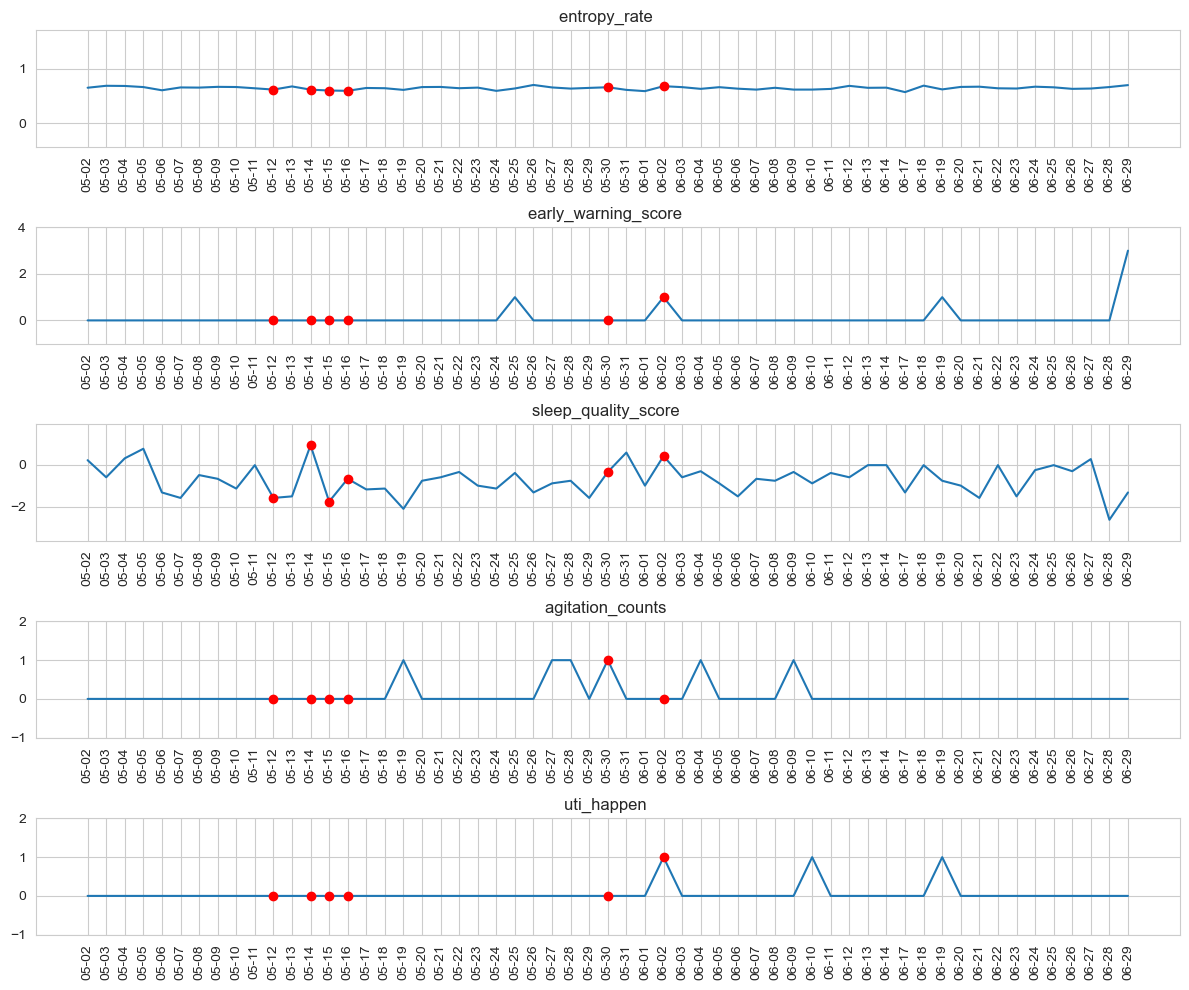

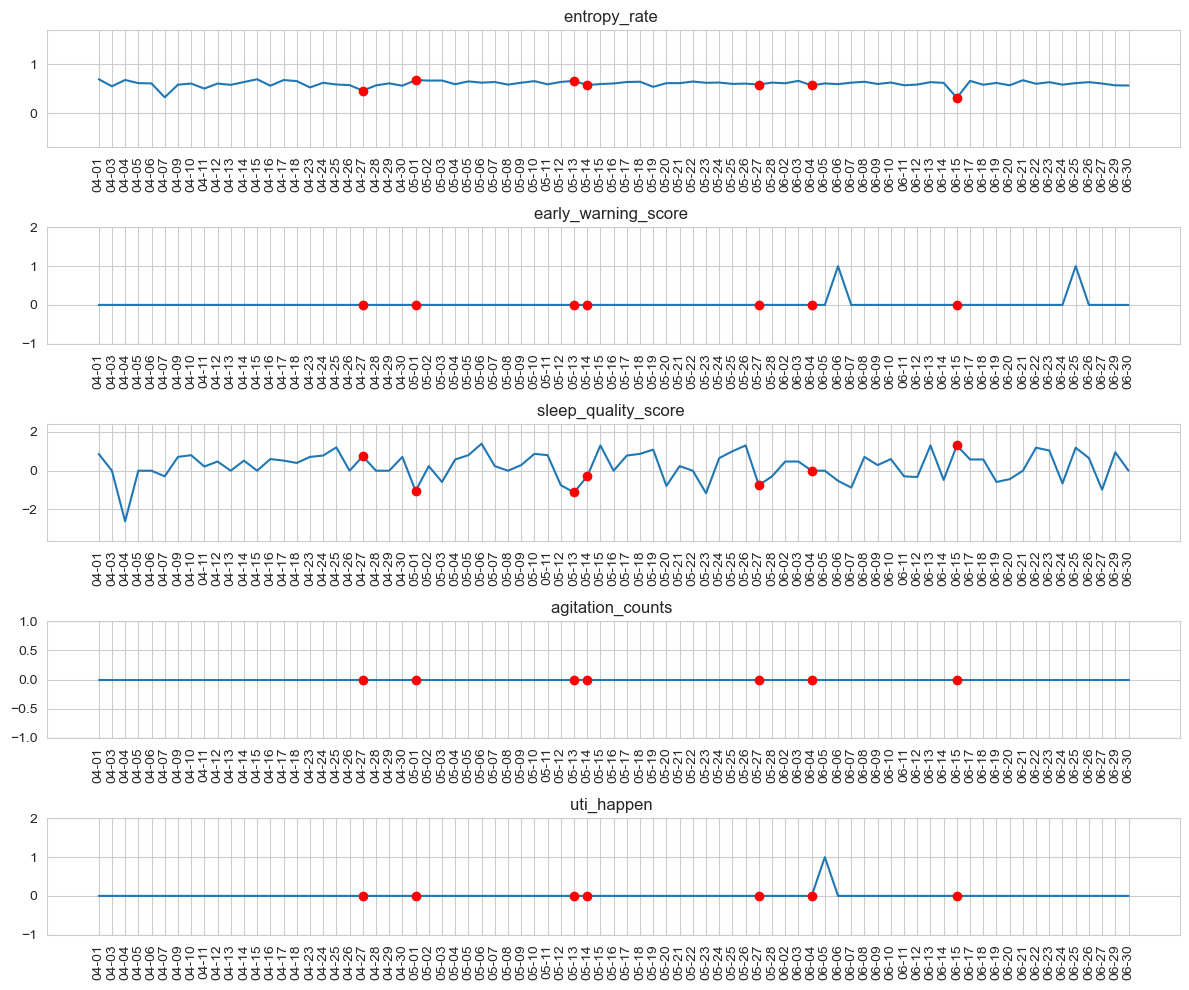

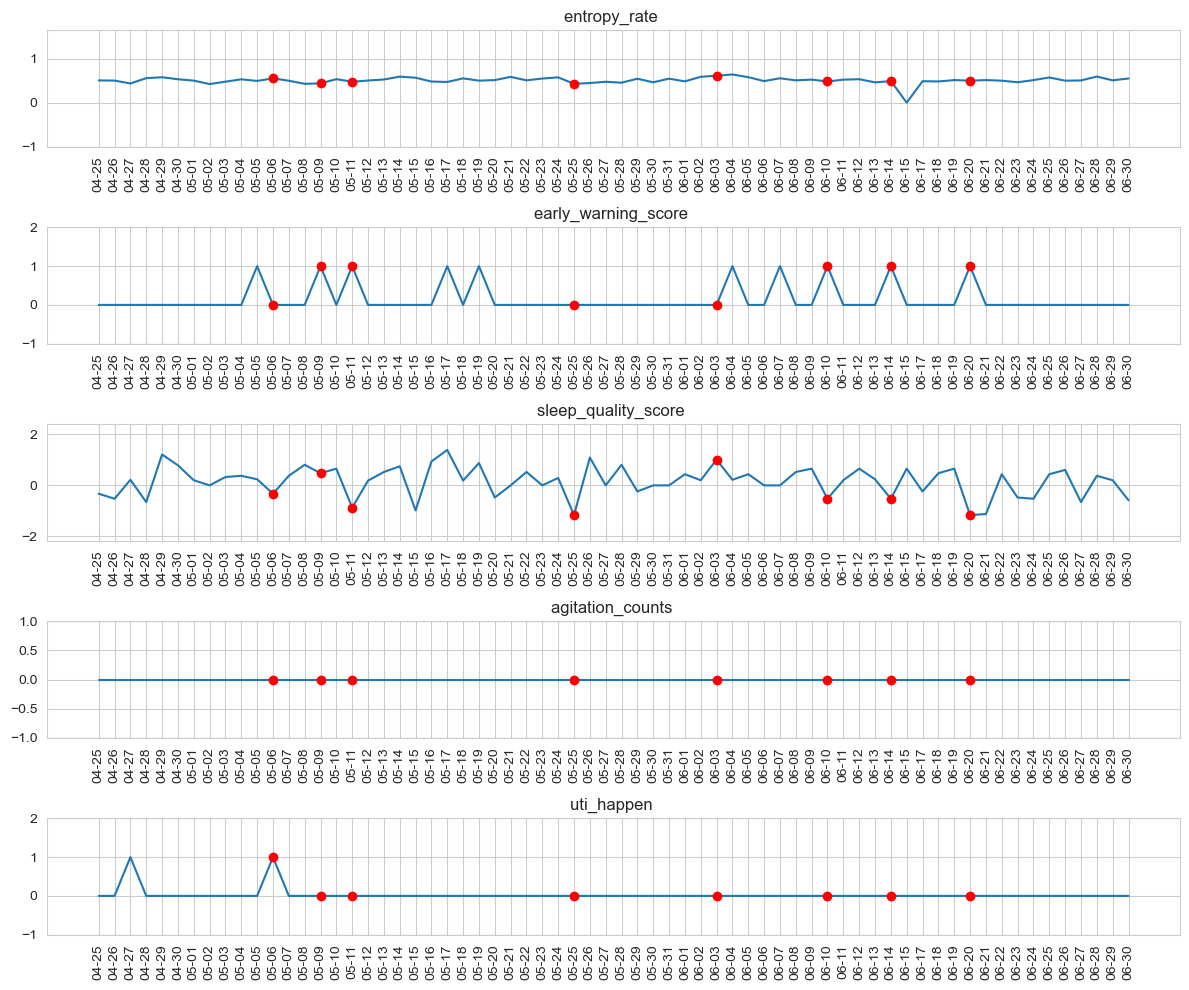

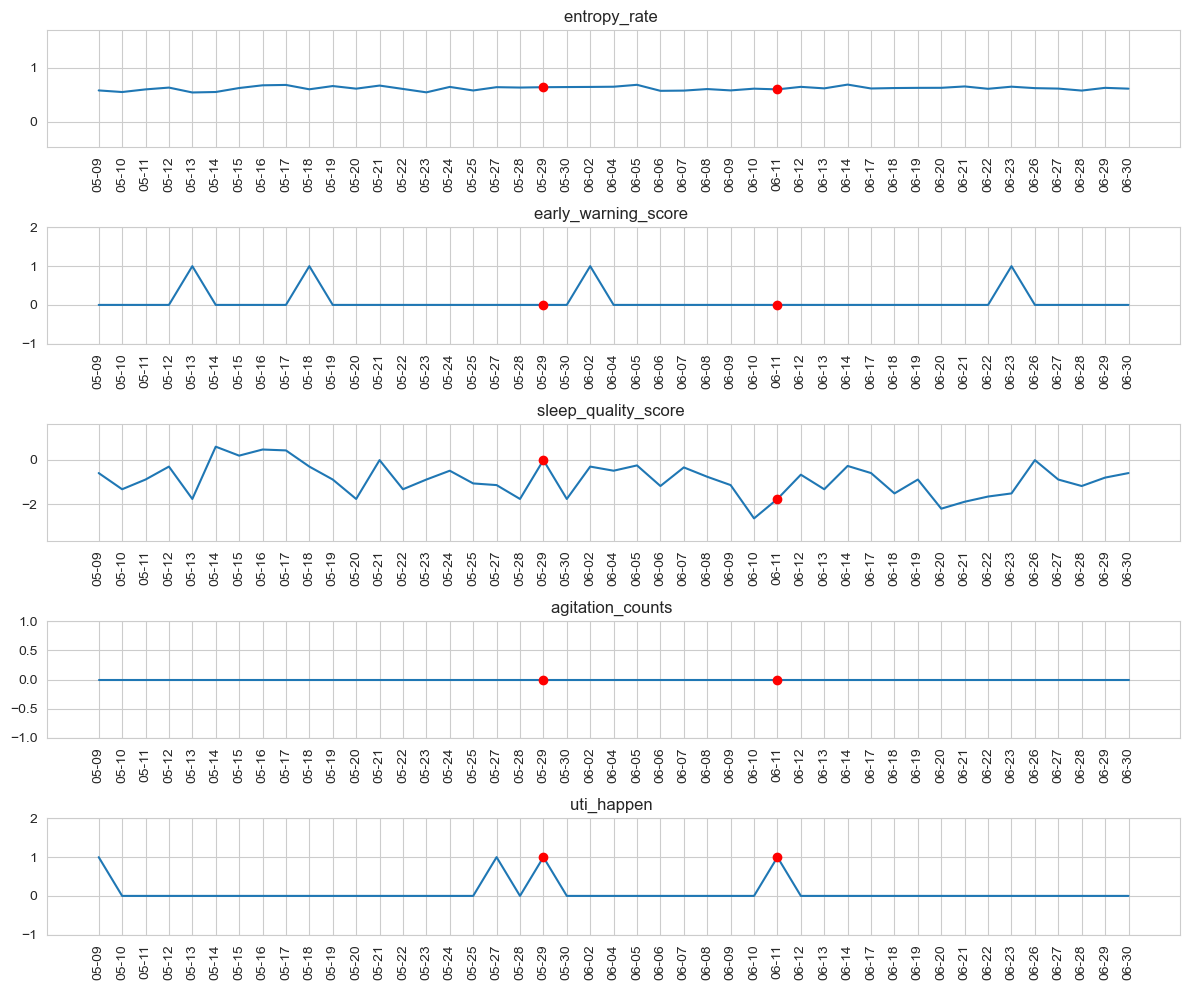

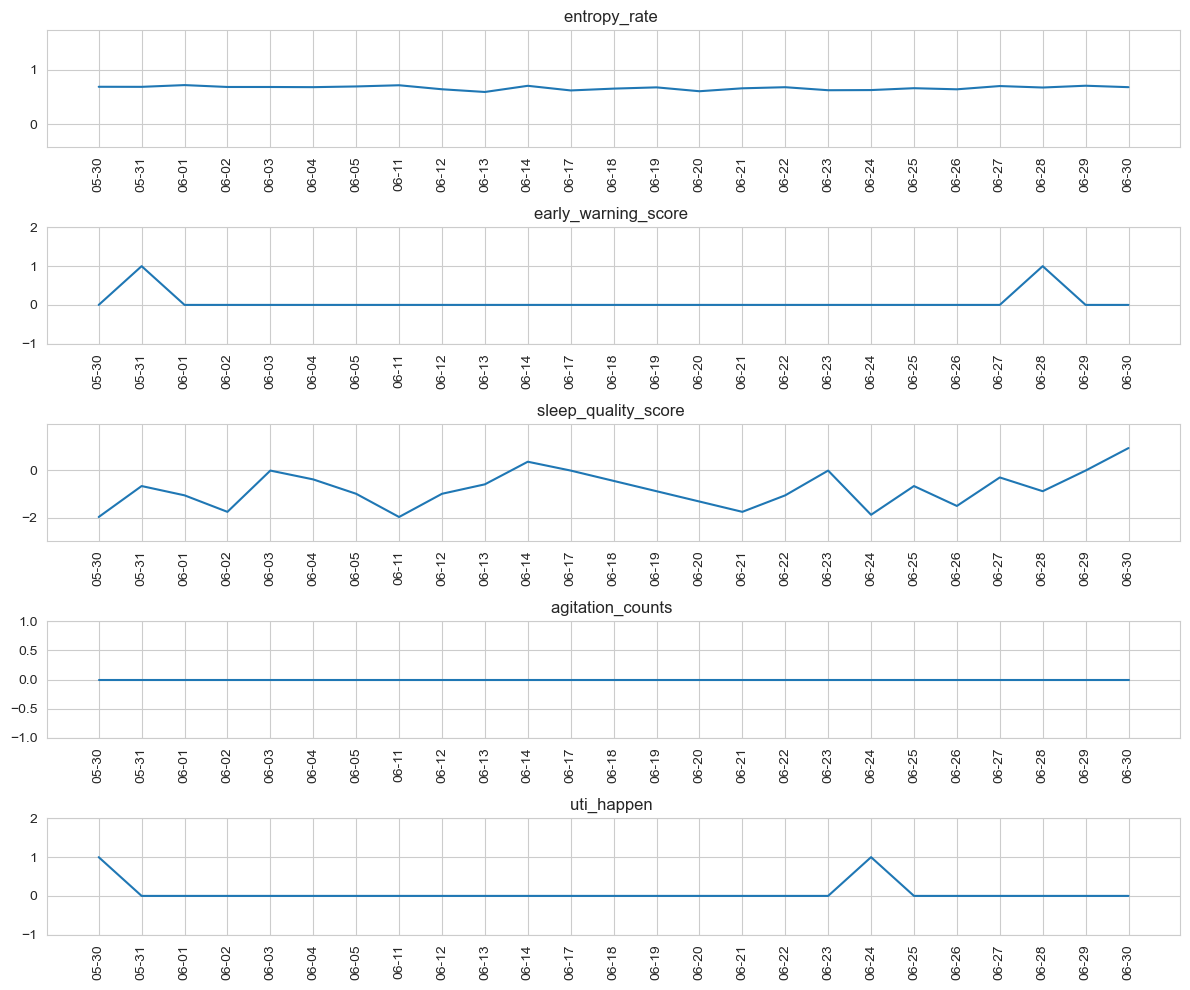

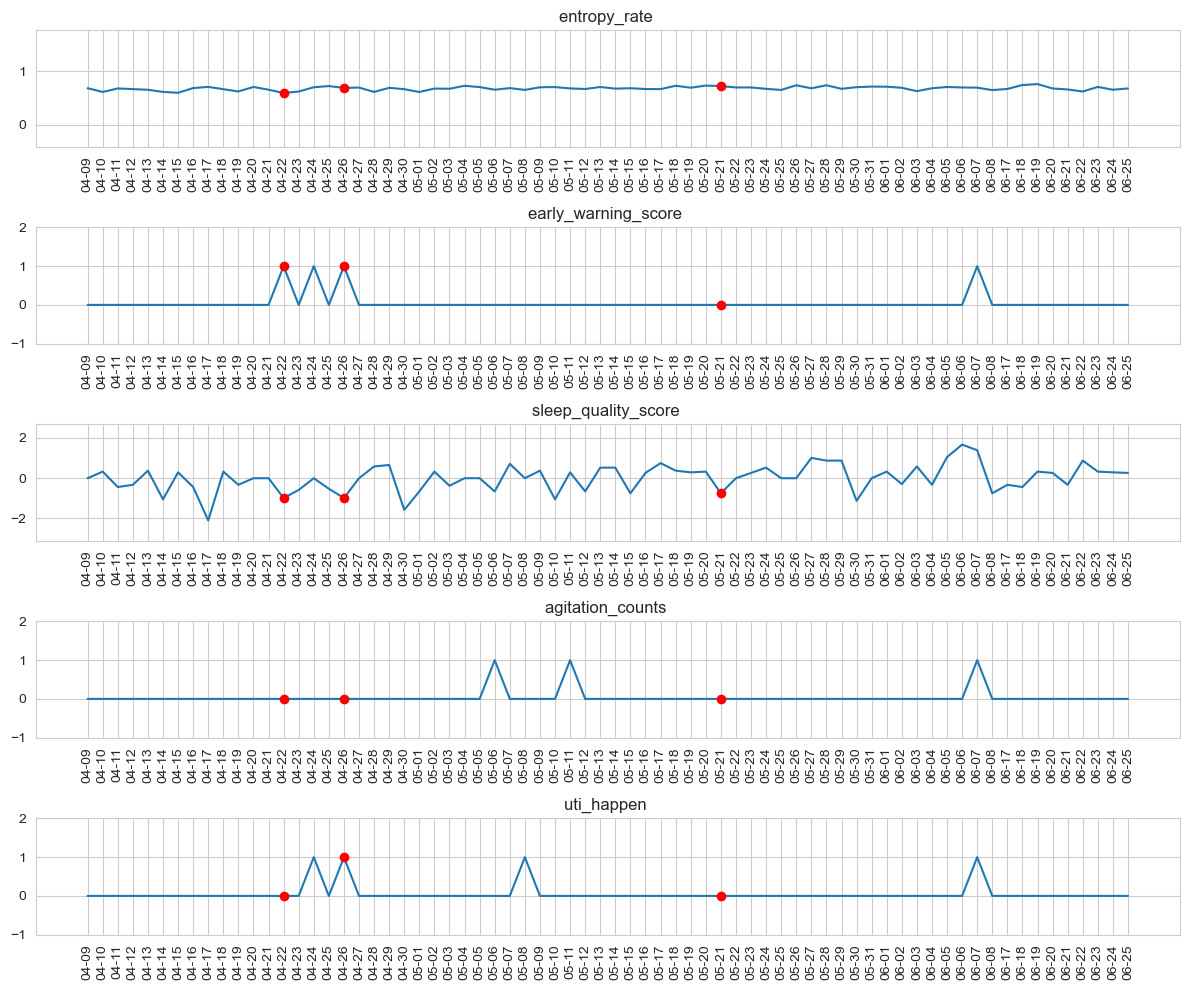

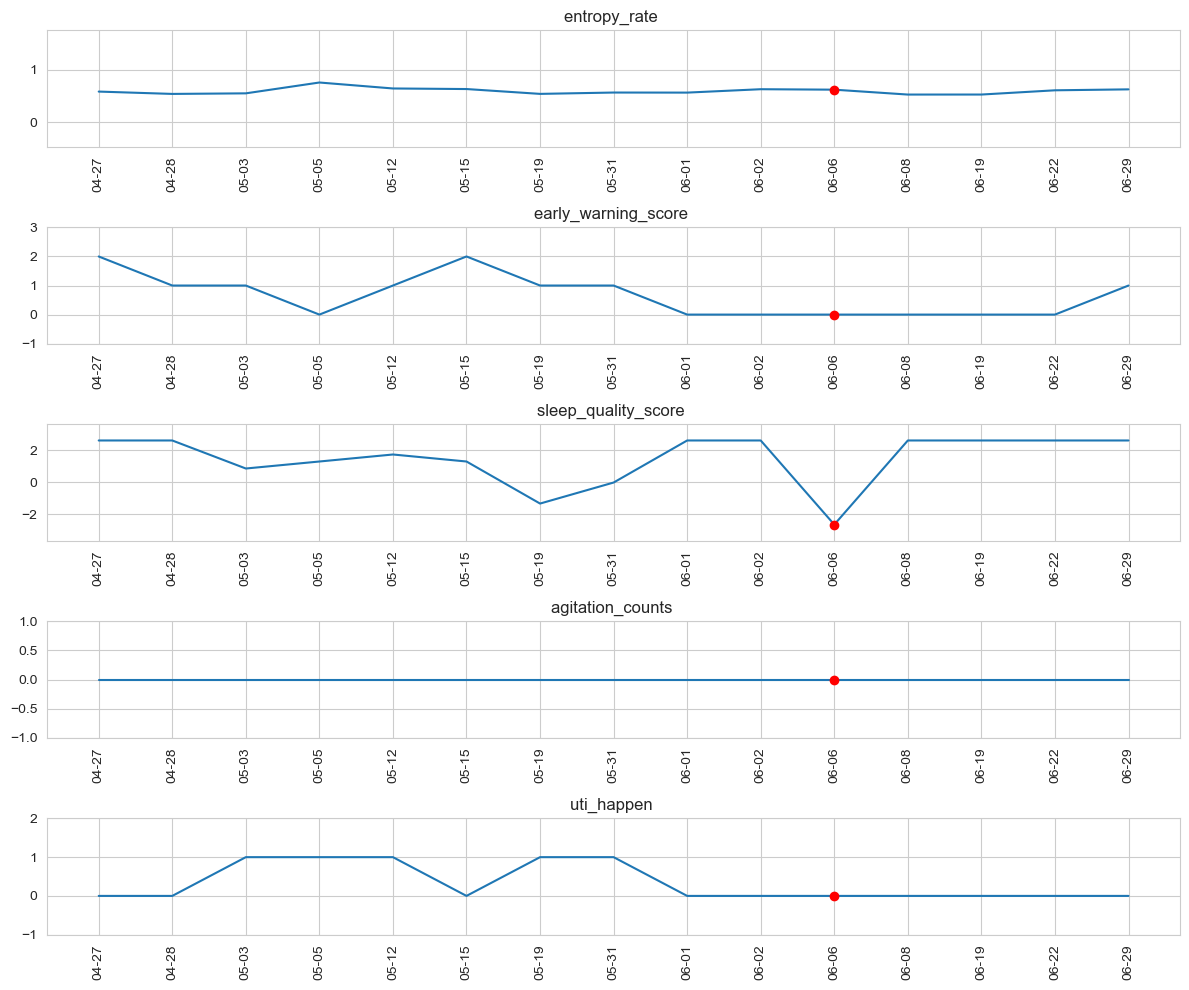

In [70]:
dfs_anomaly_all = []
days_baseline = 10

features = [
    'entropy_rate',
    'early_warning_score',
    'sleep_quality_score',
    'agitation_counts',
    'uti_happen'
]
        
for id_select in  analysis_df['patient_id'].unique():
    df_person = analysis_df[analysis_df['patient_id'] == id_select].copy()
    if df_person.shape[0] > days_baseline:
        
        # Sort by patient_id and date
        patient_data = df_person.sort_values(by=['patient_id', 'date']).reset_index(drop=True)
         
        previous_n = days_baseline  # number of past days used as baseline
        
        X_list = []
        y_list = []
        scalers = []  # optional: store scalers for inspection/debugging
        
        for i in range(len(patient_data) - previous_n):
            
            # ---------- historical window ----------
            X_raw = patient_data.iloc[i:i+previous_n][features].values
            
            # ---------- fit scaler on historical data only ----------
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_raw)
            
            # ---------- next-day observation ----------
            y_raw = patient_data.iloc[i+previous_n][features].values.reshape(1, -1)
            y_scaled = scaler.transform(y_raw)
            
            X_list.append(X_scaled)
            y_list.append(y_scaled.squeeze())  # shape (n_features,)
            scalers.append(scaler)
        
        # Convert to arrays
        X = np.array(X_list)  # shape: (n_windows, previous_n, n_features)
        y = np.array(y_list)  # shape: (n_windows, n_features)   
        
        # Parameters
        n_estimators = 100  # Number of trees
        contamination = 0.1  
        max_samples=0.8  # Number of samples used to train each tree (here I use fraction of total sample)
        
        # Train Isolation Forest
        iso_forest = IsolationForest(n_estimators=n_estimators,
                                    contamination=contamination,
                                    max_samples=max_samples,
                                    random_state=42)
        
        X_anomaly_list = []
        y_anomaly_list = []
        for n_input in range(len(X)): 
            iso_forest.fit(X[n_input])
            X_anomaly_list.append(iso_forest.predict(X[n_input]))
            y_anomaly_list.append(iso_forest.predict(y[n_input].reshape(1, -1)))
        
        X_anomaly = np.array(X_anomaly_list)
        y_anomaly = np.array(y_anomaly_list)
        
        # df_anomaly_combined = pd.concat([pd.DataFrame(X_anomaly[0,]), pd.DataFrame(y_anomaly)], axis=0)
        df_anomaly_combined = pd.concat([pd.DataFrame([np.nan]*previous_n), pd.DataFrame(y_anomaly)], axis=0)
        df_anomaly_combined = df_anomaly_combined.rename(columns={df_anomaly_combined.columns[0]: "anomaly_FI"})     
        
        # ADD ANOMALY LABELS TO ORIGINAL DATA
        df_person_re = df_person.reset_index(drop = True)
        df_anomaly_combined_re = df_anomaly_combined.reset_index(drop = True)
        df_person_plot = pd.concat([df_person_re, df_anomaly_combined_re], axis=1).copy()
        
        # Set the figure size
        import matplotlib.pyplot as plt
        
        plt.figure(figsize=(12, 10))
        anomaly_dates = pd.to_datetime(df_person_plot[df_person_plot.anomaly_FI == -1].date).dt.strftime('%m-%d').astype(str).values
        # collect the anomaly info for cross-method comparison
        anomaly_df = pd.DataFrame(anomaly_dates, columns = ['date'])
        anomaly_df['patient_id'] = id_select
        dfs_anomaly_all.append(anomaly_df)   

        
        data_plot = df_person_plot[['date', 'entropy_rate', 'early_warning_score', 'sleep_quality_score', 'agitation_counts', 'uti_happen']].copy()
        data_plot['date'] = pd.to_datetime(data_plot['date'])            
        data_plot['date'] = data_plot['date'].dt.strftime('%m-%d')
        data_plot['date'] = data_plot['date'].astype(str)             
        data_plot.set_index('date', inplace=True)
        
        
        # Plot each variable
        for i, column in enumerate(data_plot.columns):
            plt.subplot(5, 1, i+1)  # 3x3 grid for 7 variables, including empty ones for better arrangement
            plt.plot(data_plot.index, data_plot[column], label=column)
            
            # # Highlight specific index in red
            plt.scatter(anomaly_dates, data_plot[column][anomaly_dates], color='red', label='anomaly', zorder=5)
               
            # Title and labels
            plt.title(f'{column} ')
            plt.xlabel('')
            plt.ylabel('')
            plt.xticks(rotation=90)
            
            # Optional: Adjusting the y-axis range to fit all data in the plots
            plt.ylim(data_plot[column].min() - 1, data_plot[column].max() + 1)
        
        # Adjust layout and show plot
        plt.tight_layout()
        
        plt.savefig('../output/Anomaly_delirium/forest_isolation_sliding/anomaly_ForestIsolation_' + id_select + '.png', dpi=300)
        # plt.show()
        
dfs_anomaly_all = pd.concat(dfs_anomaly_all, ignore_index=True)   
dfs_anomaly_all.to_csv("../output/Anomaly_delirium/forest_isolation_sliding/forest_isolation_anomaly_data.csv", index=False)        